# Computational Statistical Mechanics - pamuduamarasinghe

# Detailed Balance Condition & Metropolis Algorithm

# 1) 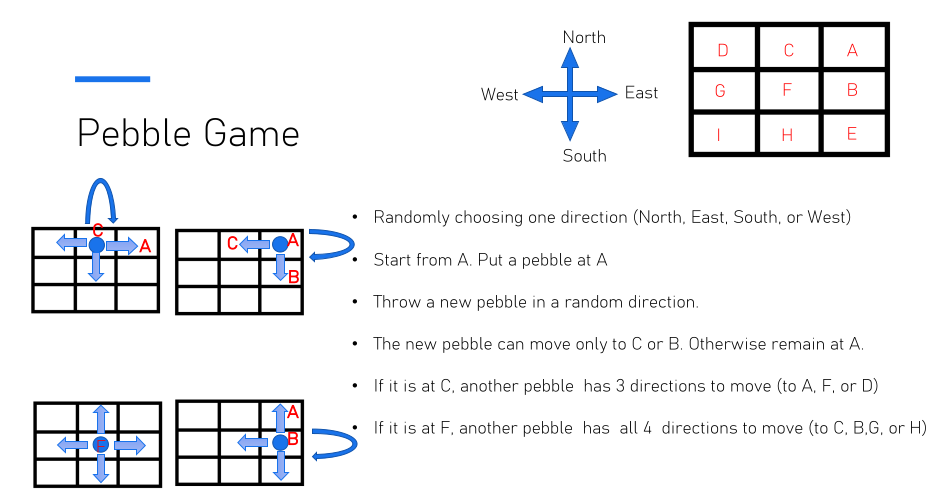

The global balance condition is a set of equations that describes the equilibrium distribution of a
Markov chain.

# homogeneous pebble game for 3 × 3 system.

In [48]:
import cv2
import numpy as np
import random 
import statistics as stat
import matplotlib.pyplot as plt

table = {'A' : ['A','A','B','C'],'B' : ['A','B','E','F'],'C' : ['C','A','F','D'],'D' : ['D','C','G','D'],
         'E' : ['B','E','E','H'],'F' : ['C','B','H','G'],'G' : ['D','F','I','G'],'H' : ['F','E','H','I'],
         'I' : ['G','H','I','I'],}

scores = {'A':0,'B':0,'C':0,'D':0,'E':0,'F':0,'G':0,'H':0,'I':0}


#no of iterations

def balance_detail(N):
    pos ='A'
    for i in range(N):
        direct =random.randint(0,3)
        pos=table[pos][direct]
        scores[pos]+=1

itr = 10
N=10000
for j in range(itr):
    balance_detail(N)

print("\nAverage hits(scores)")

for site in scores.keys():
    scores[site] = scores[site]/itr

for site in scores.keys():
    s =scores[site]
    print ("{0} : {1:8.4f}".format(site,s))


print("\nProbabilities")

probability = {'A':0,'B':0,'C':0,'D':0,'E':0,'F':0,'G':0,'H':0,'I':0}




for site in scores.keys():
    probability[site] = scores[site]/N

for site in scores.keys():
    p =probability[site]
    print ("{0} : {1:8.4f}".format(site,p))

print("\nTrue probabiltiy : {0:8.4}".format(1/9))




Average hits(scores)
A : 1122.3000
B : 1072.0000
C : 1141.8000
D : 1129.0000
E : 1075.8000
F : 1104.6000
G : 1130.2000
H : 1104.3000
I : 1120.0000

Probabilities
A :   0.1122
B :   0.1072
C :   0.1142
D :   0.1129
E :   0.1076
F :   0.1105
G :   0.1130
H :   0.1104
I :   0.1120

True probabiltiy :   0.1111


# homogeneous pebble game for 4 × 4 system.

In [49]:
#4x4 table
table_4x4 ={}
scores_4x4 ={}

#sites
sites_4x4 = []
for i in range(4):
    for j in range(4):
        site_name = f"{i},{j}"
        sites_4x4.append(site_name)
        scores_4x4[site_name] = 0

# transition table
for i in range(4):
    for j in range(4):
        site = f"{i},{j}"
        neighbors = []
        # North (index 0)
        if i > 0:
            neighbors.append(f"{i-1},{j}")
        else:
            neighbors.append(site)
        # South (index 1)
        if i < 3:
            neighbors.append(f"{i+1},{j}")
        else:
            neighbors.append(site)
        # West (index 2)
        if j > 0:
            neighbors.append(f"{i},{j-1}")
        else:
            neighbors.append(site)
        # East (index 3)
        if j < 3:
            neighbors.append(f"{i},{j+1}")
        else:
            neighbors.append(site)
        table_4x4[site] = neighbors




def balance_detail_4x4(N):
    pos = '0,0'
    for i in range(N):
        direct = random.randint(0,3)
        pos = table_4x4[pos][direct]
        scores_4x4[pos] += 1

for site in scores_4x4.keys():
    scores_4x4[site] = 0            

itr = 10
N = 100000
for j in range(itr):
    balance_detail_4x4(N)


print("4x4 Homogeneous Pebble Game Results")


print("\nAverage hits(scores)")
for site in scores_4x4.keys():
    scores_4x4[site] = scores_4x4[site]/itr


print("\nSelected sites (corners and center):")
corner_sites = ['0,0', '0,3', '3,0', '3,3']
center_sites = ['1,1', '1,2', '2,1', '2,2']
for site in corner_sites + center_sites[:2]:
    s = scores_4x4[site]
    print("{0} : {1:8.4f}".format(site,s))

print("\nProbabilities")
print("Stationary probability for a single site analytically = 1/16 = {0:8.4f}".format(1/16))

print("\nNumerical probabilities for selected sites:")
for site in corner_sites:
    p = scores_4x4[site]/N
    print("{0} : {1:8.4f}".format(site,p))

# Calculate average probability
total_prob = 0
for site in scores_4x4.keys():
    total_prob += scores_4x4[site]/N
avg_prob = total_prob/16
print("\nAverage numerical probability : {0:8.4f}".format(avg_prob))


4x4 Homogeneous Pebble Game Results

Average hits(scores)

Selected sites (corners and center):
0,0 : 6247.2000
0,3 : 6293.7000
3,0 : 6238.0000
3,3 : 6223.5000
1,1 : 6251.4000
1,2 : 6191.6000

Probabilities
Stationary probability for a single site analytically = 1/16 =   0.0625

Numerical probabilities for selected sites:
0,0 :   0.0625
0,3 :   0.0629
3,0 :   0.0624
3,3 :   0.0622

Average numerical probability :   0.0625


# Inhomogeneous pebble game

![Screenshot From 2026-07-19 13-45-50 (Edited).png](<attachment:Screenshot From 2026-07-19 13-45-50 (Edited).png>)

In [50]:
# 4x4 inhomogeneous system values
inhom_values_4x4 = [
    [2.0, 2.0, 2.0, 2.0],
    [2.0, 1.0, 1.0, 2.0],
    [2.0, 1.0, 2.0, 2.0],
    [2.0, 2.0, 2.0, 2.0]
]

# Create weights and table for 4x4 inhomogeneous
weights_4x4 = {}
scores_inhom_4x4 = {}
table_inhom_4x4 = {}

for i in range(4):
    for j in range(4):
        site = f"{i},{j}"
        weights_4x4[site] = inhom_values_4x4[i][j]
        scores_inhom_4x4[site] = 0

# transition table
for i in range(4):
    for j in range(4):
        site = f"{i},{j}"
        neighbors = []
        # North
        if i > 0:
            neighbors.append(f"{i-1},{j}")
        else:
            neighbors.append(site)
        # South
        if i < 3:
            neighbors.append(f"{i+1},{j}")
        else:
            neighbors.append(site)
        # West
        if j > 0:
            neighbors.append(f"{i},{j-1}")
        else:
            neighbors.append(site)
        # East
        if j < 3:
            neighbors.append(f"{i},{j+1}")
        else:
            neighbors.append(site)
        table_inhom_4x4[site] = neighbors

def metropolis_4x4(N):
    pos0 = '0,0'
    w0 = weights_4x4[pos0]
    for i in range(N):
        direct = random.randint(0,3)
        pos1 = table_inhom_4x4[pos0][direct]
        w1 = weights_4x4[pos1]
        L = w1/w0
        v = min([1,L])
        ran_num = random.uniform(0,1)
        if(ran_num < v):
            pos0 = pos1
            w0 = w1
        scores_inhom_4x4[pos0] += 1

itr = 10
N = 100000
for j in range(itr):
    metropolis_4x4(N)


print("4x4 Inhomogeneous Pebble Game Results")


print("\nAverage hits(scores) - Selected sites:")
for site in scores_inhom_4x4.keys():
    scores_inhom_4x4[site] = scores_inhom_4x4[site]/itr


selected = ['0,0', '1,1', '1,2', '2,1', '2,2', '3,3']
for site in selected:
    s = scores_inhom_4x4[site]
    print("{0} : {1:8.4f}".format(site,s))

print("\nComputed Stationary Probabilities (selected sites):")
for site in selected:
    p = scores_inhom_4x4[site]/N
    print("{0} : {1:8.4f}".format(site,p))

print("\nExpected Stationary Distribution (Normalized weights):")
total_weight = 0
for pos in weights_4x4.keys():
    total_weight = total_weight + weights_4x4[pos]
for site in selected:
    w = weights_4x4[site]/total_weight
    print("{0}: {1:8.4f}".format(site, w))

4x4 Inhomogeneous Pebble Game Results

Average hits(scores) - Selected sites:
0,0 : 6901.7000
1,1 : 3455.1000
1,2 : 3463.0000
2,1 : 3427.9000
2,2 : 6933.3000
3,3 : 6877.4000

Computed Stationary Probabilities (selected sites):
0,0 :   0.0690
1,1 :   0.0346
1,2 :   0.0346
2,1 :   0.0343
2,2 :   0.0693
3,3 :   0.0688

Expected Stationary Distribution (Normalized weights):
0,0:   0.0690
1,1:   0.0345
1,2:   0.0345
2,1:   0.0345
2,2:   0.0690
3,3:   0.0690


# Application of the Metropolis Algorithm

Sampling a system based on the Gaussian probability distribution

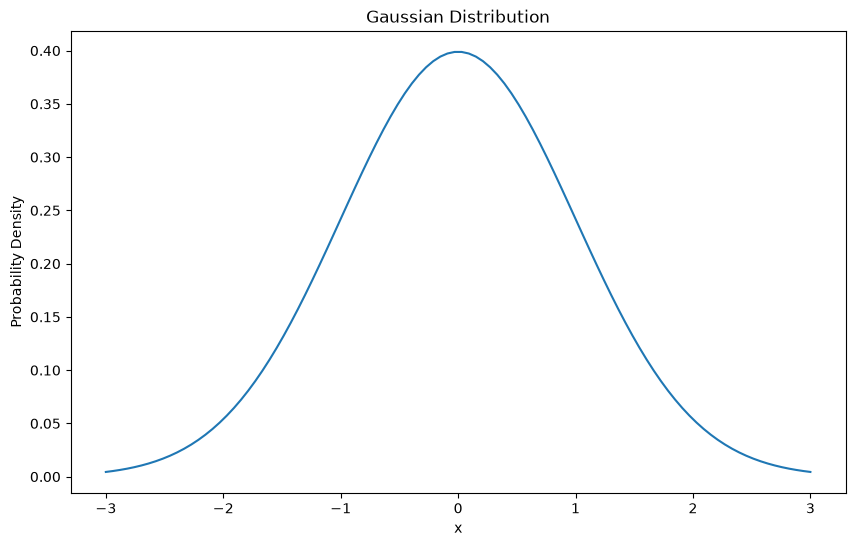

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
import random


mu = 0
variance = 1
sigma = math.sqrt(variance)

x=np.linspace(mu -3*sigma, mu + 3*sigma, 100)
y =stats.norm.pdf(x,mu,sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title('Gaussian Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.show()

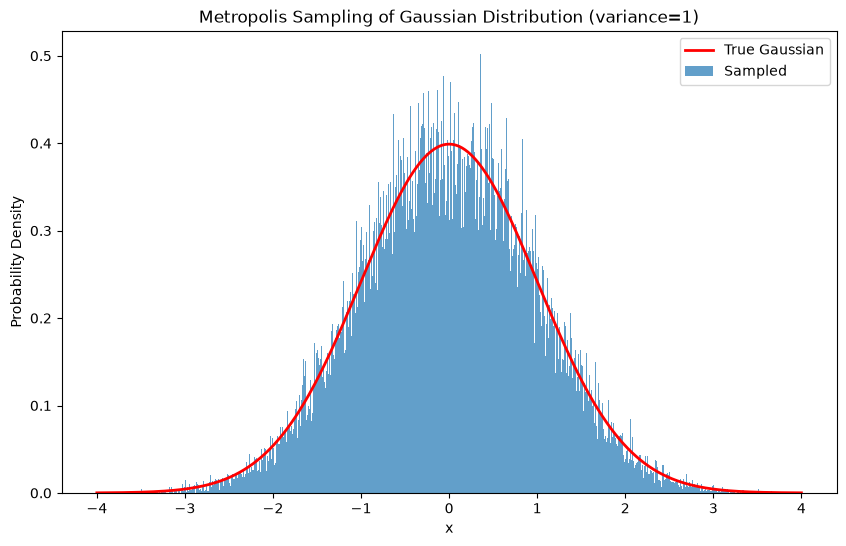

In [52]:
# Metropolis sampling for Gaussian
def metropolis_gaussian(N, mu, variance):
    sigma = math.sqrt(variance)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
    y = stats.norm.pdf(x, mu, sigma)
    
    i = 0
    results = []
    x0 = x[i]
    p0 = y[i]
    
    for n in range(N):
        i = random.randint(0, len(x)-1)
        x1 = x[i]
        p1 = y[i]
        L = p1/p0
        v = min([1,L])
        ran_num = random.uniform(0,1)
        if(ran_num < v):
            x0 = x1
            p0 = p1
            results.append(x1)
        else:
            results.append(x0)
    
    return results, x, y


results, x_new, y_new = metropolis_gaussian(100000, mu=0,variance=1)

plt.figure(figsize=(10, 6))
plt.plot(x_new,y_new ,'r-', label='True Gaussian', linewidth=2)
plt.hist(results, bins=x_new, density=True, alpha=0.7, label='Sampled')
plt.title('Metropolis Sampling of Gaussian Distribution (variance=1)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

Sampling a system based on Boltzmann distribution 

P(i) = A*exp(-Ei/kT)

𝐴 is a constant (A=1), 𝑇 is temperature, 𝑘 is Boltzmann constant and 𝜀! is the
energy at 𝑖 th state.

Boltzmann Distribution Sampling


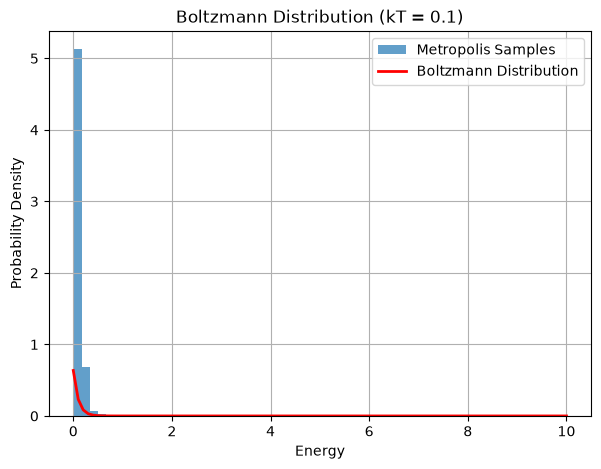

kT = 0.1
Mean Energy = 0.067
Most Probable Energy = 0.000




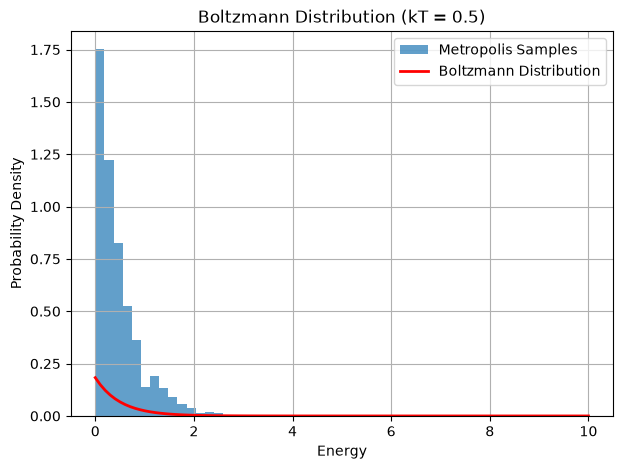

kT = 0.5
Mean Energy = 0.453
Most Probable Energy = 0.000




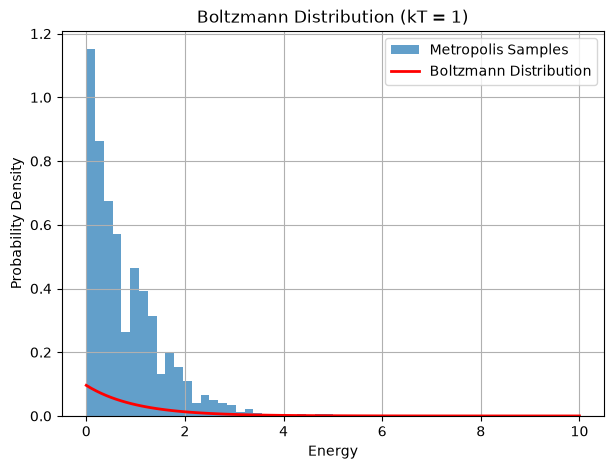

kT = 1
Mean Energy = 0.793
Most Probable Energy = 0.000




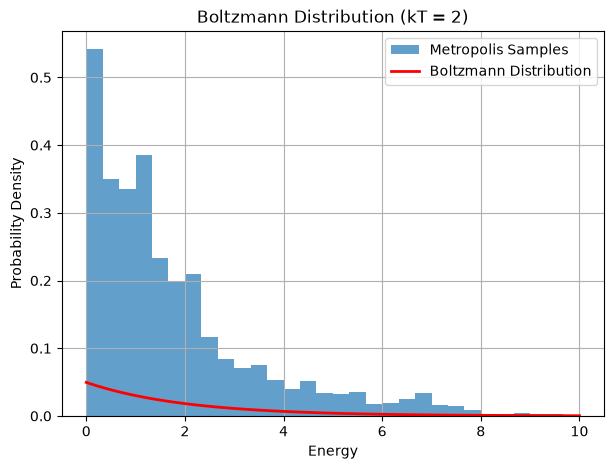

kT = 2
Mean Energy = 1.779
Most Probable Energy = 0.000




In [53]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Metropolis sampling for Boltzmann distribution
def metropolis_boltzmann(kT, N=50000):

    energies = np.linspace(0, 10, 100)

    # Boltzmann distribution
    prob = np.exp(-energies / kT)
    prob = prob / np.sum(prob)

    current = 50 #middle index         
    samples = []

    for n in range(N):

       
        step = random.choice([-1, 1])
        proposed = current + step

      
        if proposed < 0:
            proposed = 0
        elif proposed >= len(energies):
            proposed = len(energies) - 1

        # Acceptance probability
        L = prob[proposed] / prob[current]
        v = min(1, L)

        if random.random() < v:
            current = proposed

        samples.append(energies[current])

    return samples, energies, prob


kT_values = [0.1, 0.5, 1, 2]

print("Boltzmann Distribution Sampling")

for kT in kT_values:

    samples, energies, prob = metropolis_boltzmann(kT)

    plt.figure(figsize=(7,5))

    plt.hist(samples,bins=30,density=True,alpha=0.7,label="Metropolis Samples")
    plt.plot(energies,prob,'r-',linewidth=2,label="Boltzmann Distribution")

    plt.title(f"Boltzmann Distribution (kT = {kT})")
    plt.xlabel("Energy")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"kT = {kT}")
    print(f"Mean Energy = {np.mean(samples):.3f}")
    print(f"Most Probable Energy = {energies[np.argmax(prob)]:.3f}")
    print("\n")